# **Dataset Download & Setup**

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/white-blood-cells-dataset")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 499M/499M [00:17<00:00, 30.1MB/s]

Extracting files...


Path to dataset files: C:\Users\archa\.cache\kagglehub\datasets\masoudnickparvar\white-blood-cells-dataset\versions\1


# **Data Loading & Preprocessing**

In [3]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



base_path = "/kaggle/input/white-blood-cells-dataset"

train_path = base_path + "/Train"
testA_path = base_path + "/Test-A"
testB_path = base_path + "/Test-B"



train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

testA_dataset = datasets.ImageFolder(
    root=testA_path,
    transform=test_transform
)

testB_dataset = datasets.ImageFolder(
    root=testB_path,
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

testA_loader = DataLoader(
    testA_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

testB_loader = DataLoader(
    testB_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)


print("Train Classes:", train_dataset.classes)
print("Number of Classes:", len(train_dataset.classes))

Train Classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Number of Classes: 5


# **ResNet-50 (Baseline CNN)**

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)


num_features = model_resnet.fc.in_features

for param in model_resnet.parameters():
    param.requires_grad = False

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 5)



model_resnet = model_resnet.to(device)

print(model_resnet)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# **Vision Transformer (ViT)**

In [5]:
import torch
import torch.nn as nn
from transformers import ViTForImageClassification


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model_vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=5,
    ignore_mismatched_sizes=True
)
for param in model_vit.vit.parameters():
    param.requires_grad = False

model_vit = model_vit.to(device)

print(model_vit)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

# **Hybrid CNN + ViT Model (PyTorch Implementation)**

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

class HybridCNNViT(nn.Module):
    def __init__(self, num_classes=5, embed_dim=512, num_heads=8, num_layers=2):
        super(HybridCNNViT, self).__init__()

        # CNN backbone (ResNet50)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Freeze CNN layers
        for param in self.cnn_backbone.parameters():
            param.requires_grad = False

        # Reduce channels
        self.conv_reduce = nn.Conv2d(2048, embed_dim, kernel_size=1)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):


        x = self.cnn_backbone(x)


        x = self.conv_reduce(x)

        B, C, H, W = x.shape


        x = x.view(B, C, H*W)
        x = x.permute(0, 2, 1)


        x = self.transformer(x)

        x = x.mean(dim=1)


        x = self.classifier(x)

        return x

In [7]:
model_hybrid = HybridCNNViT(num_classes=5)
model_hybrid = model_hybrid.to(device)

print(model_hybrid)

HybridCNNViT(
  (cnn_backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): C

# **Training Loop**

**Training Function (Reused for All Models)**

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [10]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [11]:
def train_model(model, train_loader, val_loader, epochs=6, lr=3e-4):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2
    )

    scaler = GradScaler()
    early_stopping = EarlyStopping(patience=3)

    for epoch in range(epochs):


        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(images)


                if hasattr(outputs, "logits"):
                    outputs = outputs.logits

                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                with autocast():
                    outputs = model(images)

                    if hasattr(outputs, "logits"):
                        outputs = outputs.logits

                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"| Train Acc: {train_accuracy:.2f}% "
              f"| Val Acc: {val_accuracy:.2f}%")

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    return model

In [12]:
trained_resnet = train_model(
    model_resnet,
    train_loader,
    testA_loader,
    epochs=3
)

/tmp/ipykernel_1009/1185890197.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_1009/1185890197.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1009/1185890197.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/3] | Train Acc: 67.96% | Val Acc: 77.78%
Epoch [2/3] | Train Acc: 77.69% | Val Acc: 79.97%
Epoch [3/3] | Train Acc: 81.05% | Val Acc: 83.43%


In [13]:
trained_vit = train_model(
    model_vit,
    train_loader,
    testA_loader,
    epochs=3
)

/tmp/ipykernel_1009/1185890197.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_1009/1185890197.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1009/1185890197.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/3] | Train Acc: 77.91% | Val Acc: 86.06%
Epoch [2/3] | Train Acc: 88.60% | Val Acc: 90.83%
Epoch [3/3] | Train Acc: 91.52% | Val Acc: 91.50%


In [14]:
trained_hybrid = train_model(
    model_hybrid,
    train_loader,
    testA_loader,
    epochs=3
)

/tmp/ipykernel_1009/1185890197.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_1009/1185890197.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1009/1185890197.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/3] | Train Acc: 72.14% | Val Acc: 89.08%
Epoch [2/3] | Train Acc: 92.38% | Val Acc: 93.36%
Epoch [3/3] | Train Acc: 94.25% | Val Acc: 93.02%


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

In [16]:
def evaluate_model(model, dataloader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)


            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)

    return acc, precision, recall, f1, cm

In [17]:
print("ResNet Results")
evaluate_model(trained_resnet, testA_loader)

ResNet Results
Accuracy: 0.8333717446416224
Precision: 0.8278553545929733
Recall: 0.8333717446416224
F1 Score: 0.8241352144789271
Confusion Matrix:
 [[  86    0    1    0    2]
 [   0  128   55   11  128]
 [   1    9  871    6  147]
 [   0    6   51   97   80]
 [   0   40  170   16 2434]]


(0.8333717446416224,
 0.8278553545929733,
 0.8333717446416224,
 0.8241352144789271,
 array([[  86,    0,    1,    0,    2],
        [   0,  128,   55,   11,  128],
        [   1,    9,  871,    6,  147],
        [   0,    6,   51,   97,   80],
        [   0,   40,  170,   16, 2434]]))

In [18]:
print("ViT Results")
evaluate_model(trained_vit, testA_loader)

ViT Results
Accuracy: 0.9144964277483291
Precision: 0.9153703361021872
Recall: 0.9144964277483291
F1 Score: 0.9105746862839431
Confusion Matrix:
 [[  59    0   25    5    0]
 [   0  224   28    3   67]
 [   0   13 1004    4   13]
 [   0   23   64  114   33]
 [   0   68   22    3 2567]]


(0.9144964277483291,
 0.9153703361021872,
 0.9144964277483291,
 0.9105746862839431,
 array([[  59,    0,   25,    5,    0],
        [   0,  224,   28,    3,   67],
        [   0,   13, 1004,    4,   13],
        [   0,   23,   64,  114,   33],
        [   0,   68,   22,    3, 2567]]))

In [19]:
print("Hybrid Model Results")
evaluate_model(trained_hybrid, testA_loader)

Hybrid Model Results
Accuracy: 0.9303987093800414
Precision: 0.9395422270827858
Recall: 0.9303987093800414
F1 Score: 0.9333892562259091
Confusion Matrix:
 [[  89    0    0    0    0]
 [   1  285    3   15   18]
 [   1    8  969   28   28]
 [   0    8   13  197   16]
 [   1  108    7   47 2497]]


(0.9303987093800414,
 0.9395422270827858,
 0.9303987093800414,
 0.9333892562259091,
 array([[  89,    0,    0,    0,    0],
        [   1,  285,    3,   15,   18],
        [   1,    8,  969,   28,   28],
        [   0,    8,   13,  197,   16],
        [   1,  108,    7,   47, 2497]]))

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(cm, class_names):

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Accuracy: 0.8333717446416224
Precision: 0.8278553545929733
Recall: 0.8333717446416224
F1 Score: 0.8241352144789271
Confusion Matrix:
 [[  86    0    1    0    2]
 [   0  128   55   11  128]
 [   1    9  871    6  147]
 [   0    6   51   97   80]
 [   0   40  170   16 2434]]


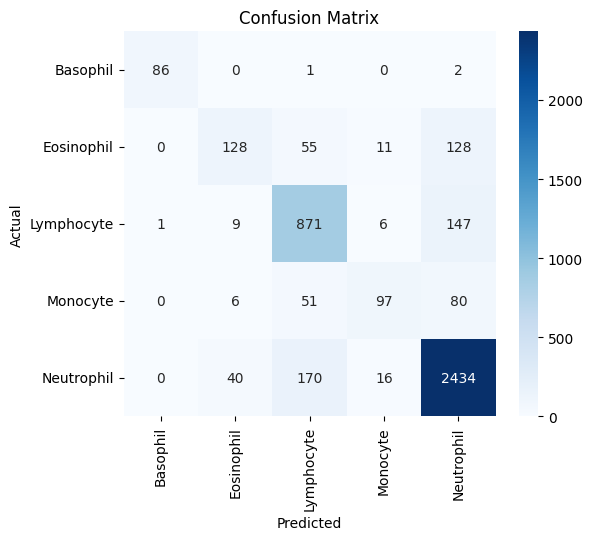

In [21]:
acc, precision, recall, f1, cm = evaluate_model(trained_resnet, testA_loader)

plot_confusion(cm, train_dataset.classes)

Accuracy: 0.8333717446416224
Precision: 0.8278553545929733
Recall: 0.8333717446416224
F1 Score: 0.8241352144789271
Confusion Matrix:
 [[  86    0    1    0    2]
 [   0  128   55   11  128]
 [   1    9  871    6  147]
 [   0    6   51   97   80]
 [   0   40  170   16 2434]]


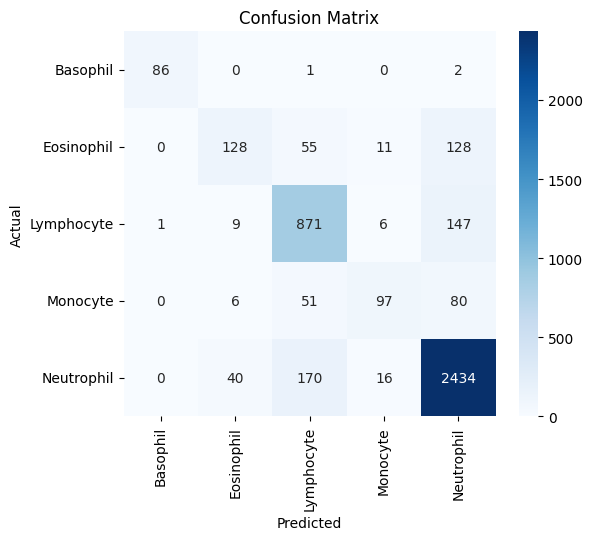

In [22]:
acc, precision, recall, f1, cm = evaluate_model(trained_resnet, testA_loader)

plot_confusion(cm, train_dataset.classes)

Accuracy: 0.9303987093800414
Precision: 0.9395422270827858
Recall: 0.9303987093800414
F1 Score: 0.9333892562259091
Confusion Matrix:
 [[  89    0    0    0    0]
 [   1  285    3   15   18]
 [   1    8  969   28   28]
 [   0    8   13  197   16]
 [   1  108    7   47 2497]]


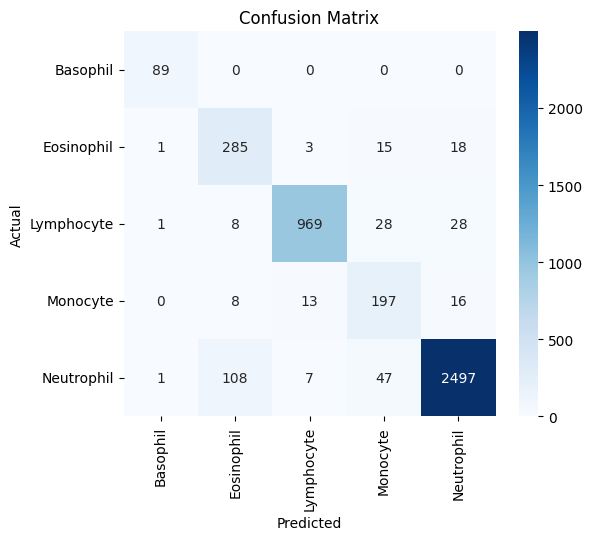

In [23]:
acc, precision, recall, f1, cm = evaluate_model(trained_hybrid, testA_loader)

plot_confusion(cm, train_dataset.classes)

In [24]:
resnet_results = evaluate_model(trained_resnet, testA_loader)
vit_results = evaluate_model(trained_vit, testA_loader)
hybrid_results = evaluate_model(trained_hybrid, testA_loader)

Accuracy: 0.8333717446416224
Precision: 0.8278553545929733
Recall: 0.8333717446416224
F1 Score: 0.8241352144789271
Confusion Matrix:
 [[  86    0    1    0    2]
 [   0  128   55   11  128]
 [   1    9  871    6  147]
 [   0    6   51   97   80]
 [   0   40  170   16 2434]]
Accuracy: 0.9144964277483291
Precision: 0.9153703361021872
Recall: 0.9144964277483291
F1 Score: 0.9105746862839431
Confusion Matrix:
 [[  59    0   25    5    0]
 [   0  224   28    3   67]
 [   0   13 1004    4   13]
 [   0   23   64  114   33]
 [   0   68   22    3 2567]]
Accuracy: 0.9303987093800414
Precision: 0.9395422270827858
Recall: 0.9303987093800414
F1 Score: 0.9333892562259091
Confusion Matrix:
 [[  89    0    0    0    0]
 [   1  285    3   15   18]
 [   1    8  969   28   28]
 [   0    8   13  197   16]
 [   1  108    7   47 2497]]


In [25]:
resnet_acc = resnet_results[0]
vit_acc = vit_results[0]
hybrid_acc = hybrid_results[0]

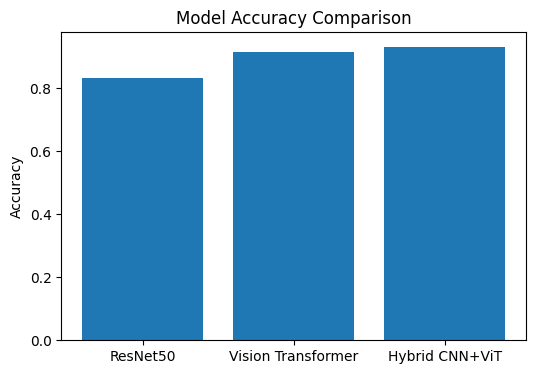

In [26]:
import matplotlib.pyplot as plt

models = ["ResNet50", "Vision Transformer", "Hybrid CNN+ViT"]
accuracies = [resnet_acc, vit_acc, hybrid_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

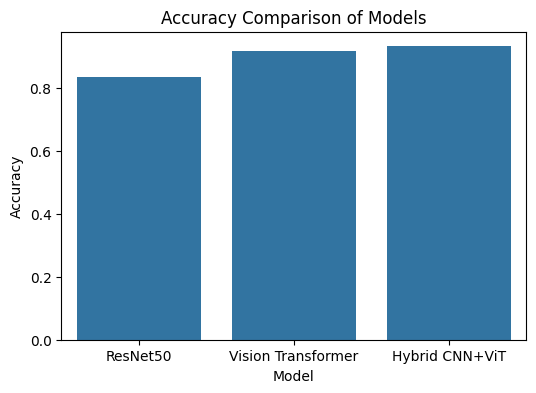

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

models = ["ResNet50", "Vision Transformer", "Hybrid CNN+ViT"]
accuracies = [resnet_acc, vit_acc, hybrid_acc]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()